In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [156]:
from google.colab import files
uploaded = files.upload()

Saving Bengaluru_House_Data.csv to Bengaluru_House_Data (3).csv


In [157]:
df= pd.read_csv("Bengaluru_House_Data.csv")

In [158]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [159]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns)
print("Dataset Information:")
df.info()

Shape: (13320, 9)
Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [160]:
print(df.duplicated().sum())

529


In [161]:
df.drop_duplicates(inplace=True)

In [162]:
print(df.duplicated().sum())

0


In [163]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns)
print("Dataset Information:")
df.info()

Shape: (12791, 9)
Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12790 non-null  object 
 3   size          12775 non-null  object 
 4   society       7463 non-null   object 
 5   total_sqft    12791 non-null  object 
 6   bath          12718 non-null  float64
 7   balcony       12186 non-null  float64
 8   price         12791 non-null  float64
dtypes: float64(3), object(6)
memory usage: 999.3+ KB


In [164]:
df.describe()

,bath,balcony,price
count,12718.000000,12186.000000,12791.000000
mean,2.708602,1.582308,114.317646
std,1.357764,0.822536,151.480310
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,73.000000
75%,3.000000,2.000000,121.000000
max,40.000000,3.000000,3600.000000


In [165]:
df = df.dropna(
    subset=["location", "size", "total_sqft", "price"]
)

In [166]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,5325
total_sqft,0
bath,57
balcony,589
price,0


In [167]:
df["size"].head(20)

,size
0,2 BHK
1,4 Bedroom
2,3 BHK
3,3 BHK
4,2 BHK
5,2 BHK
6,4 BHK
7,4 BHK
8,3 BHK
9,6 Bedroom


In [168]:
df["size"].value_counts()

,count
size,
2 BHK,4931
3 BHK,4119
4 Bedroom,824
4 BHK,574
3 Bedroom,535
1 BHK,521
2 Bedroom,314
5 Bedroom,291
6 Bedroom,191


In [169]:
df["size"] = df["size"].str.strip()
df["availability"] = df["availability"].str.strip()
df["location"] = df["location"].str.strip()
df["society"] = df["society"].str.strip()
df["total_sqft"] = df["total_sqft"].str.strip()
df["area_type"] = df["area_type"].str.strip()

In [170]:
df["room_count"] = df["size"].str.split().str[0].astype(float)

In [171]:
df["property_type"] = df["size"].str.split().str[1]

In [172]:
print(df["room_count"].isnull().sum())
print(df["property_type"].isnull().sum())
print(df["property_type"].value_counts(dropna=False))

0
0
property_type
BHK        10273
Bedroom     2488
RK            13
Name: count, dtype: int64


In [173]:
def convert_sqft(x):
    try:
        if "-" in str(x):
            values = str(x).split("-")
            return (float(values[0]) + float(values[1])) / 2
        return float(x)
    except:
        return None

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

In [174]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["room_count"] = pd.to_numeric(df["room_count"], errors="coerce")

In [175]:
df = df.dropna(subset=["total_sqft", "price", "room_count"])

In [176]:
df = df[
    (df["total_sqft"] > 0) &
    (df["price"] > 0) &
    (df["room_count"] > 0)
].copy()

In [177]:
df["society"] = df.groupby("location")["society"].transform(
    lambda x: x.fillna(
        x.mode().iloc[0] if not x.mode().empty else "Unknown"
    )
)

In [178]:
df["society"] = df["society"].fillna("Unknown")

In [179]:
df["price_per_sqft"] = (
    df["price"] * 100000
) / df["total_sqft"]

df["sqft_per_room"] = (
    df["total_sqft"] / df["room_count"]
)

In [180]:
print(df.columns.tolist())

['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price', 'room_count', 'property_type', 'price_per_sqft', 'sqft_per_room']


In [181]:
print("New Features Created:")
print(df[
    [
        "total_sqft",
        "room_count",
        "price",
        "price_per_sqft",
        "sqft_per_room",
        "society"
    ]
].head())

New Features Created:
   total_sqft  room_count   price  price_per_sqft  sqft_per_room  society
0      1056.0         2.0   39.07     3699.810606          528.0   Coomee
1      2600.0         4.0  120.00     4615.384615          650.0  Theanmp
2      1440.0         3.0   62.00     4305.555556          480.0  Aklia R
3      1521.0         3.0   95.00     6245.890861          507.0  Soiewre
4      1200.0         2.0   51.00     4250.000000          600.0  Somumys


In [182]:
print("\nMissing Values:")
print(df[[
    "total_sqft",
    "room_count",
    "price",
    "price_per_sqft",
    "sqft_per_room",
    "society"
]].isnull().sum())


Missing Values:
total_sqft        0
room_count        0
price             0
price_per_sqft    0
sqft_per_room     0
society           0
dtype: int64


In [183]:
print("\nUnknown Society Count:")
print((df["society"] == "Unknown").sum())
print("\nFinal Dataset Shape:", df.shape)


Unknown Society Count:
1367

Final Dataset Shape: (12728, 13)


In [184]:
if "bath" in df.columns:
    df["bath"] = pd.to_numeric(
        df["bath"], errors="coerce"
    )
    df.loc[
        (df["bath"] < 0) | (df["bath"] > 20),
        "bath"
    ] = np.nan
    df["bath"] = df["bath"].fillna(
        df["bath"].median()
    )
else:
    df["bath"] = 0

In [185]:
if "balcony" in df.columns:
    df["balcony"] = pd.to_numeric(
        df["balcony"], errors="coerce"
    )
    df.loc[
        (df["balcony"] < 0) | (df["balcony"] > 10),
        "balcony"
    ] = np.nan
    df["balcony"] = df["balcony"].fillna(
        df["balcony"].median()
    )
else:
    df["balcony"] = 0

In [186]:
if "availability" in df.columns:
    df["availability"] = (
        df["availability"]
        .astype("string")
        .str.strip()
    )
    df["availability"] = df["availability"].replace("", pd.NA)
    df["availability"] = df["availability"].fillna("Unknown")
    df["availability"] = df["availability"].apply(
        lambda x: "Ready To Move"
        if x in ["Ready To Move", "Immediate Possession"]
        else "Future"
        if x != "Unknown"
        else "Unknown"
    )

In [187]:
print(df.columns.tolist())

['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price', 'room_count', 'property_type', 'price_per_sqft', 'sqft_per_room']


In [188]:
df = df[
    (df["sqft_per_room"] >= 300) &
    (df["room_count"] <= 10) &
    (df["bath"] <= df["room_count"] + 2)
].copy()

In [189]:
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

df = df[
    df["price_per_sqft"].between(lower, upper)
].copy()

print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (11741, 13)


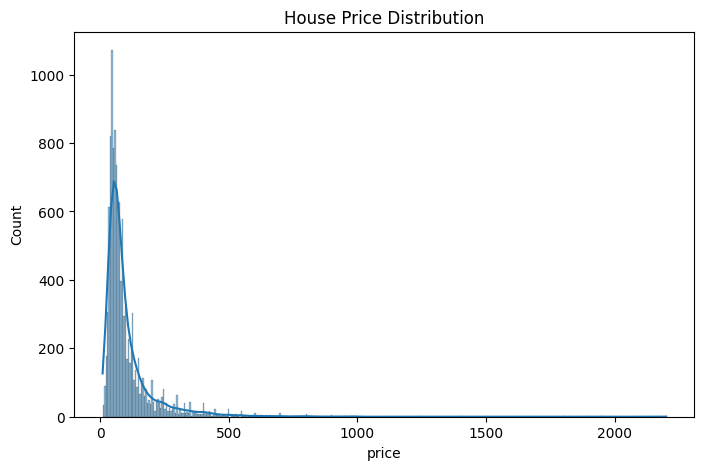

In [190]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.show()

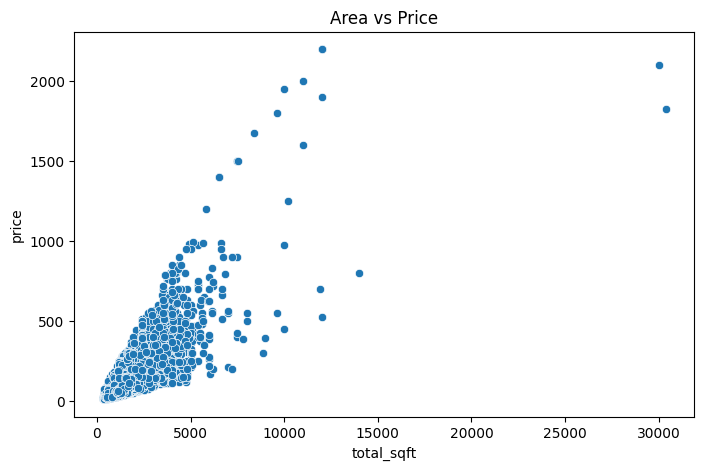

In [191]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_sqft", y="price")
plt.title("Area vs Price")
plt.show()

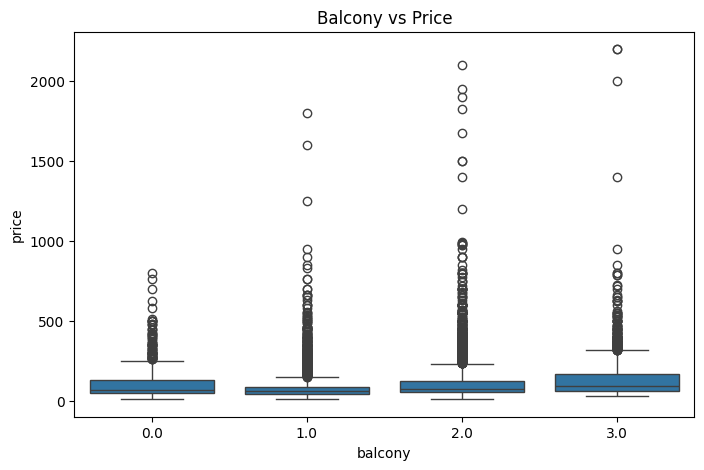

In [192]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="balcony", y="price")
plt.title("Balcony vs Price")
plt.show()

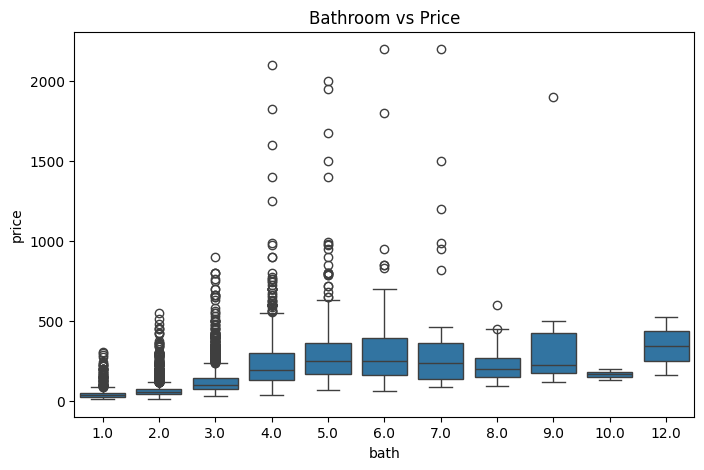

In [193]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="bath", y="price")
plt.title("Bathroom vs Price")
plt.show()

In [194]:
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.columns)

Index(['total_sqft', 'bath', 'balcony', 'price', 'room_count',
       'price_per_sqft', 'sqft_per_room'],
      dtype='object')


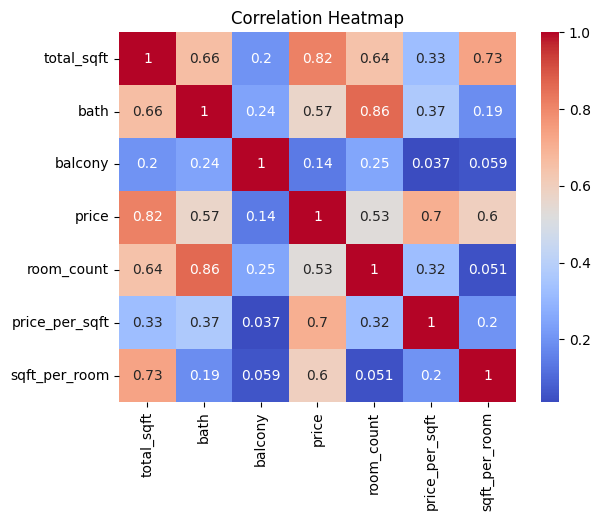

In [195]:
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [196]:
print(df.columns.tolist())

['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price', 'room_count', 'property_type', 'price_per_sqft', 'sqft_per_room']


In [211]:
features = [
    "total_sqft",
    "room_count",
    "bath",
    "balcony",
    "price_per_sqft",
    "sqft_per_room"
]

In [212]:
categorical = [
    col for col in [
        "location",
        "society",
        "area_type",
        "availability"
    ]
    if col in df.columns
]

In [213]:
features = features + categorical

In [200]:
features = [
    col for col in features
    if df[col].notna().any()
]


In [201]:
X = df[features].copy()
y = df["price"].copy()

In [202]:
X = pd.get_dummies(
    X,
    columns=categorical,
    dtype=int
)

In [203]:
X = X.fillna(X.median())

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [205]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [206]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("\nMODEL RESULTS")
print("--------------------")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))


MODEL RESULTS
--------------------
MAE: 16.63
MSE: 1233.61
RMSE: 35.12
R2 Score: 0.8863


In [207]:
y_pred = model.predict(X_test)
print("First 10 actual prices:")
print(y_test.head(10).values)
print("\nFirst 10 predicted prices:")
print(y_pred[:10])

First 10 actual prices:
[ 65.   112.   145.    55.   125.    64.39  78.   195.   289.    58.  ]

First 10 predicted prices:
[ 66.4669455  121.14252545 145.30710114  53.07797442 129.94257555
  66.42309398  78.80792414 204.10065891 259.51769663  65.70999826]


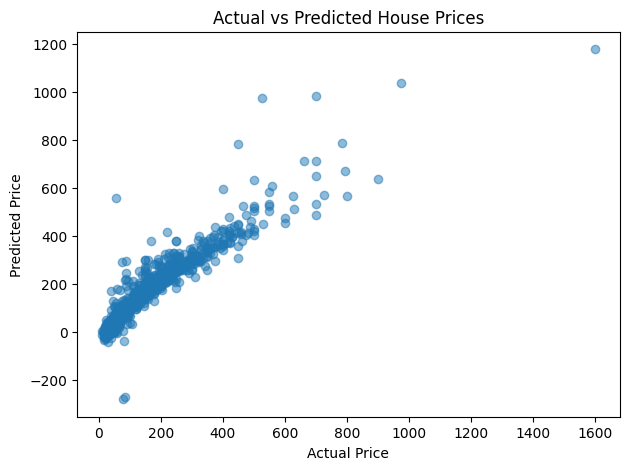

In [208]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

##balcony


In [209]:
if "balcony" in features:
    # Model without balcony
    X_without = X.drop(columns=["balcony"])
    X_train2 = X_without.loc[X_train.index]
    X_test2 = X_without.loc[X_test.index]
    model2 = LinearRegression()
    model2.fit(X_train2, y_train)
    predictions2 = model2.predict(X_test2)
    mae2 = mean_absolute_error(y_test, predictions2)
    mse2 = mean_squared_error(y_test, predictions2)
    rmse2 = np.sqrt(
        mean_squared_error(y_test, predictions2)
    )
    r22 = r2_score(y_test, predictions2)
    print("\nMODEL WITHOUT BALCONY")
    print("--------------------")
    print("MAE:", round(mae2, 2))
    print("MSE:", round(mse2, 2))
    print("RMSE:", round(rmse2, 2))
    print("R2 Score:", round(r22, 4))


MODEL WITHOUT BALCONY
--------------------
MAE: 16.63
MSE: 1233.61
RMSE: 35.12
R2 Score: 0.8863


In [210]:
print("BALCONY COMPARISON")
if rmse < rmse2:
    print("Balcony include karne se RMSE improve hua.")
elif rmse2 < rmse:
    print("Balcony remove karne se RMSE improve hua.")
else:
    print("Dono models ka RMSE same hai.")
print("\nFinal Dataset Shape:", df.shape)

BALCONY COMPARISON
Balcony remove karne se RMSE improve hua.

Final Dataset Shape: (11741, 13)


Conclusion

The Bengaluru House Data dataset was cleaned and explored through visualizations to understand the relationships between house prices and different features. Feature engineering and categorical encoding were performed before applying Linear Regression. The model was trained using an 80:20 train-test split. It achieved an MAE of 16.63 lakhs,an R2 Score of 0.8863 lakhs and an RMSE of 35.12 lakhs. Actual-versus-predicted plots and residual analysis helped identify prediction errors and limitations. The results show that Linear Regression captures some patterns in house prices but does not predict all properties accurately.